<br><br>
<p style="font-size:24px; color:#216594;text-align:center;">
Applied AI in Chemical and Process Engineering
</p>

<p style="font-size:30px; color:black;text-align:center;">
    Bulding ML pipeline for Reactor data
</p>


██████████████████████████████████████████████████████████████████████
<br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/refs/heads/main/data/Ethanol_Molasses_Dataset.csv')

In [10]:
# Remove outliers using IQR method
Q1 = df_filled.quantile(0.25)
Q3 = df_filled.quantile(0.75)
IQR = Q3 - Q1

dfclean = df_filled[~((df_filled < (Q1 - 1.5 * IQR)) |(df_filled > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

print(f"Original DataFrame shape: {df_filled.shape}")
print(f"Cleaned DataFrame shape: {dfclean.shape}")

Original DataFrame shape: (972, 5)
Cleaned DataFrame shape: (964, 5)


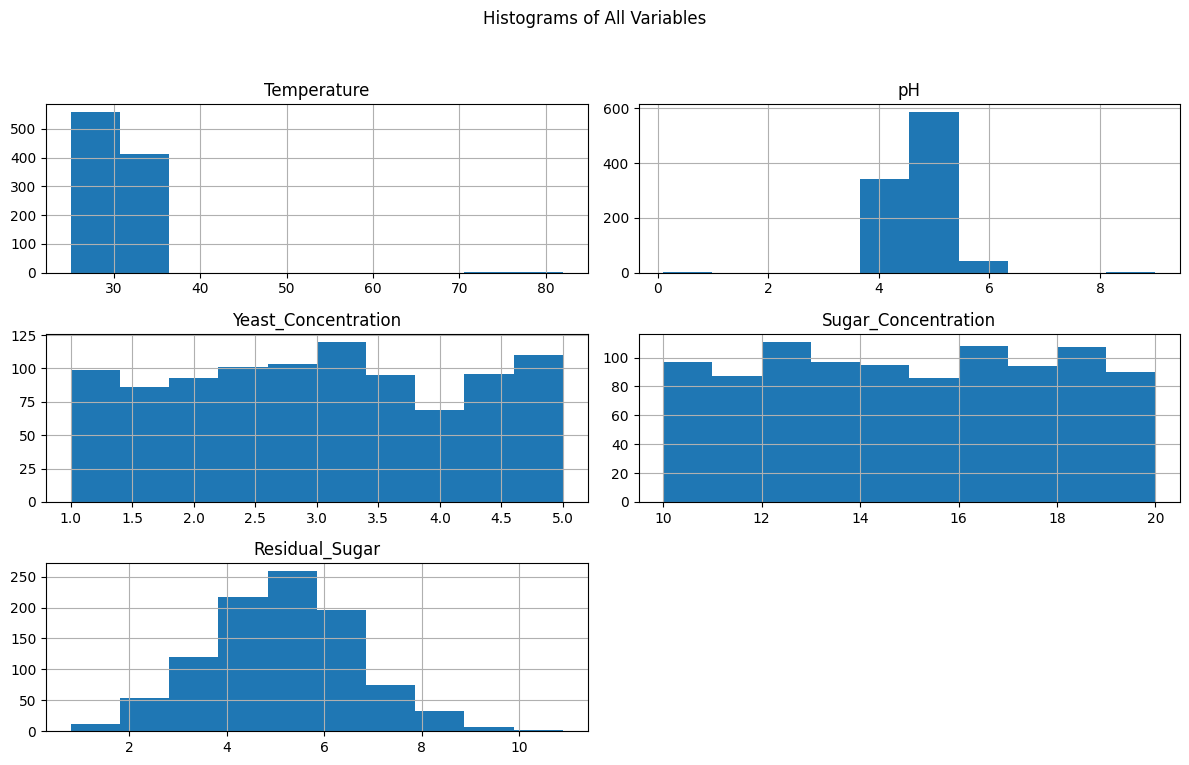

In [9]:
# Create histogram plots for all variables
df_filled.hist(figsize=(12, 8))
plt.suptitle('Histograms of All Variables')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

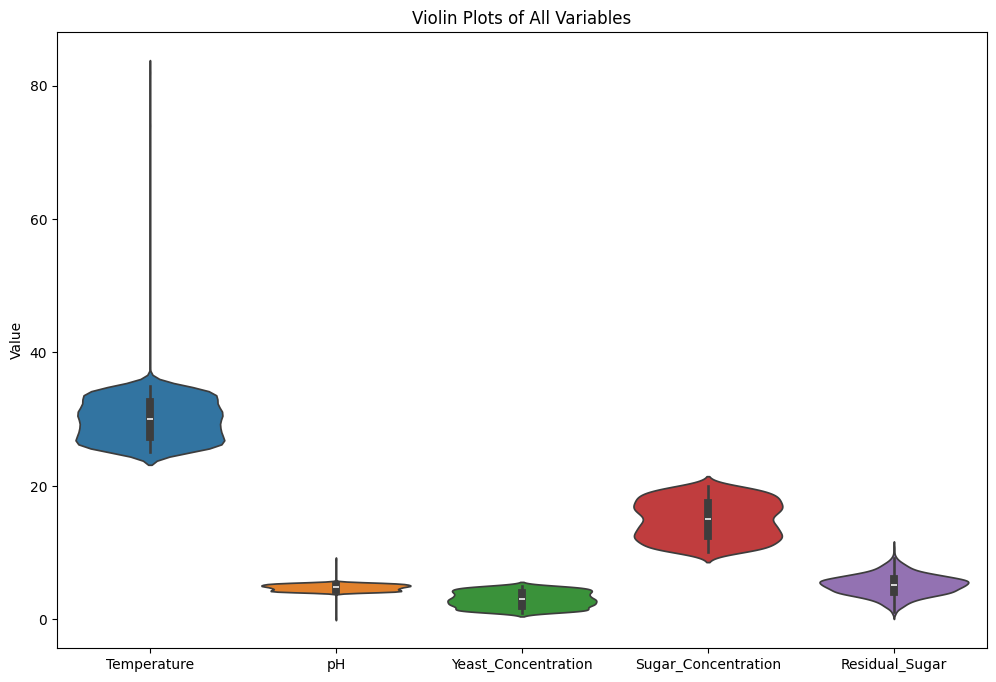

In [8]:
# Create violin plots for all variables
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_filled)
plt.title('Violin Plots of All Variables')
plt.ylabel('Value')
plt.show()

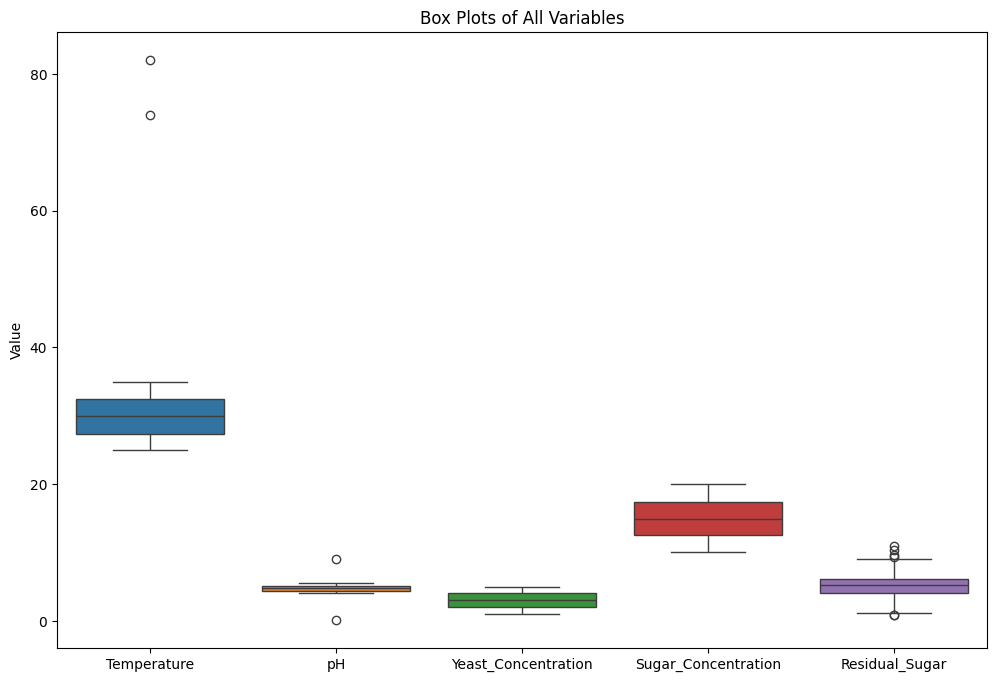

In [7]:
# Create box plots for all variables
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_filled)
plt.title('Box Plots of All Variables')
plt.ylabel('Value')
plt.show()

In [6]:
display(df_filled.describe())

,Temperature,pH,Yeast_Concentration,Sugar_Concentration,Residual_Sugar
count,972.000000,972.000000,972.000000,972.000000,972.000000
mean,30.003807,4.760802,2.982510,14.961934,5.155041
std,3.649713,0.484015,1.160695,2.852478,1.510385
min,25.000000,0.100000,1.000000,10.000000,0.800000
25%,27.375000,4.400000,2.000000,12.500000,4.100000
50%,30.000000,4.800000,3.000000,14.950000,5.200000
75%,32.500000,5.100000,4.000000,17.400000,6.100000
max,82.000000,9.000000,5.000000,20.000000,10.900000


In [5]:
print(f"Number of duplicate rows: {df_filled.duplicated().sum()}")

Number of duplicate rows: 0


In [4]:
# Fill missing data with median using SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['Sugar_Concentration'] = imputer.fit_transform(df[['Sugar_Concentration']])

# Verify that missing values are filled
print(df.isnull().sum())

# Create a new dataframe `df_filled` with the imputed data
df_filled = df.copy()

Temperature            0
pH                     0
Yeast_Concentration    0
Sugar_Concentration    0
Residual_Sugar         0
dtype: int64


In [3]:
print(df.isnull().sum())

Temperature            0
pH                     0
Yeast_Concentration    0
Sugar_Concentration    2
Residual_Sugar         0
dtype: int64


In [2]:
display(df.head(15))
print(f"DataFrame dimensions: {df.shape}")

,Temperature,pH,Yeast_Concentration,Sugar_Concentration,Residual_Sugar
0,28.7,5.0,1.2,12.3,5.3
1,34.5,5.4,2.3,10.0,5.4
2,32.3,5.1,4.1,17.3,3.2
3,31.0,4.3,3.8,19.7,2.7
4,26.6,4.0,4.2,12.2,5.5
5,26.6,4.4,3.1,16.6,5.2
6,25.6,4.9,2.8,17.4,5.2
7,33.7,4.1,1.6,18.5,7.6
8,31.0,4.7,2.3,14.2,5.1
9,32.1,4.9,2.7,13.0,3.9


DataFrame dimensions: (972, 5)



**Week 3-4**

This notebook will build a pipeline to prepare data and develop an ML algorithm


# Content

**Part 1: Data Preprocessing & Exploration**

| Step                  | Description                                                                 | Key Actions & Tools                                                                                     |
|-----------------------|-----------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------|
| **Data Preparation**  | Gather, load, and inspect raw data                                          | - Load dataset (e.g., CSV, DB)<br>- Check data types, shape, initial samples (`df.head()`, `df.info()`) |
| **Data Cleaning**     | Fix issues in data quality                                                  | - Handle missing values (impute or drop)<br>- Remove duplicates<br>- Detect and treat outliers (IQR, Z-score) |
| **Exploratory Data Analysis (EDA)** | Understand data distributions and relationships                   | - Visualizations: histograms, scatter plots, pair plots<br>- Correlation matrix (heatmaps)<br>- Summary statistics |

**Part 2: Modeling & Interpretation**

| Step                                  | Description                                                                 | Key Actions & Tools                                                                                     |
|---------------------------------------|-----------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------|
| **Normalization**    | Scale features to same range (e.g., for distance-based models)              | - Apply Min-Max Scaling or Standardization<br>- Justify choice based on model needs (e.g., SVM, KNN, Neural Networks) |
| **Model Training, Validation & Testing** | Build and evaluate model performance                                    | - Split data: `train_test_split`<br>- Train models (e.g., Linear Regression, Random Forest, XGBoost)<br>- Use cross-validation<br>- Evaluate using metrics (RMSE, MAE, R², etc.) |
| **Model Explanation with XAI**        | Interpret model predictions and feature importance                          | - Use SHAP, LIME, or feature importance plots<br>- Explain predictions to stakeholders<br>- Ensure transparency and trust |


**Part 3: Optimization**

Apply wide search strategy and Bayseian optimization to find the most optimum operating parameters

## Optimization

Now that we have a trained model, we can use it to find the optimum operating parameters (Temperature, pH, Yeast Concentration, and Sugar Concentration) to minimize the residual sugar. We will explore different optimization strategies.

**Note:** Since our example does not have categorical data, we do not encode variables - which is essential if the data is categorical

# Ethanol Production - Sugar Industry

![Process Flow Diagram](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/etoh_flowdiagram.png?raw=1)


**Our goal is to model residual sugar. The model can be later used to optimize the fermentation process**

**Data**
- Temperature °C: Fermentation tank
- pH: Fermentation tank
- Yeast Concentration g/L: Fermentation tank
- Sugar Concentration w/v: Dilution tank (input for fermenation)
- Residual Sugar g/L: Post-fermentation


Note: The data is simualted data


# Data Preperation

**Prompt:**
Load data from below github
https://raw.githubusercontent.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/refs/heads/main/data/Ethanol_Molasses_Dataset.csv


**Prompt:**

Print first 15 rows of the table and the dimensions of the table

# Data Cleaning

| Step           | Purpose                                      | Common Methods                                                                 | Notes                                                                 |
|----------------|----------------------------------------------|---------------------------------------------------------------------------------|-----------------------------------------------------------------------|
| **Missing Data** | Handle incomplete or null values             | - Remove rows/columns<br>- Impute with mean/median/mode<br>- KNN/imputation models | Can bias models; choice depends on amount and reason for missingness |
| **Duplicates**   | Remove redundant data entries                | - Identify and drop duplicate rows<br>- Use `pandas.drop_duplicates()`           | Prevents overfitting and skewed results                              |
| **Outliers**     | Detect and manage extreme values             | - Z-score, IQR method<br>- Visualization (box plots, scatter plots)<br>- Winsorizing | Can distort models; keep if meaningful (e.g., fraud detection)       |

## Check for missing data

**Prompt:**
Check if the table has missing values

Temperature            0
pH                     0
Yeast_Concentration    0
Sugar_Concentration    0
Residual_Sugar         0
dtype: int64


## Fill the missing data wiht median using imputer

**Prompt:**
Fill the missing data with median value

In [13]:
# Fill missing data with median using SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['Sugar_Concentration'] = imputer.fit_transform(df[['Sugar_Concentration']])

# Verify that missing values are filled
print(df.isnull().sum())

# Create a new dataframe `df_filled` with the imputed data
df_filled = df.copy()

Temperature            0
pH                     0
Yeast_Concentration    0
Sugar_Concentration    0
Residual_Sugar         0
dtype: int64


In [25]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (674, 4)
Testing set shape: (290, 4)


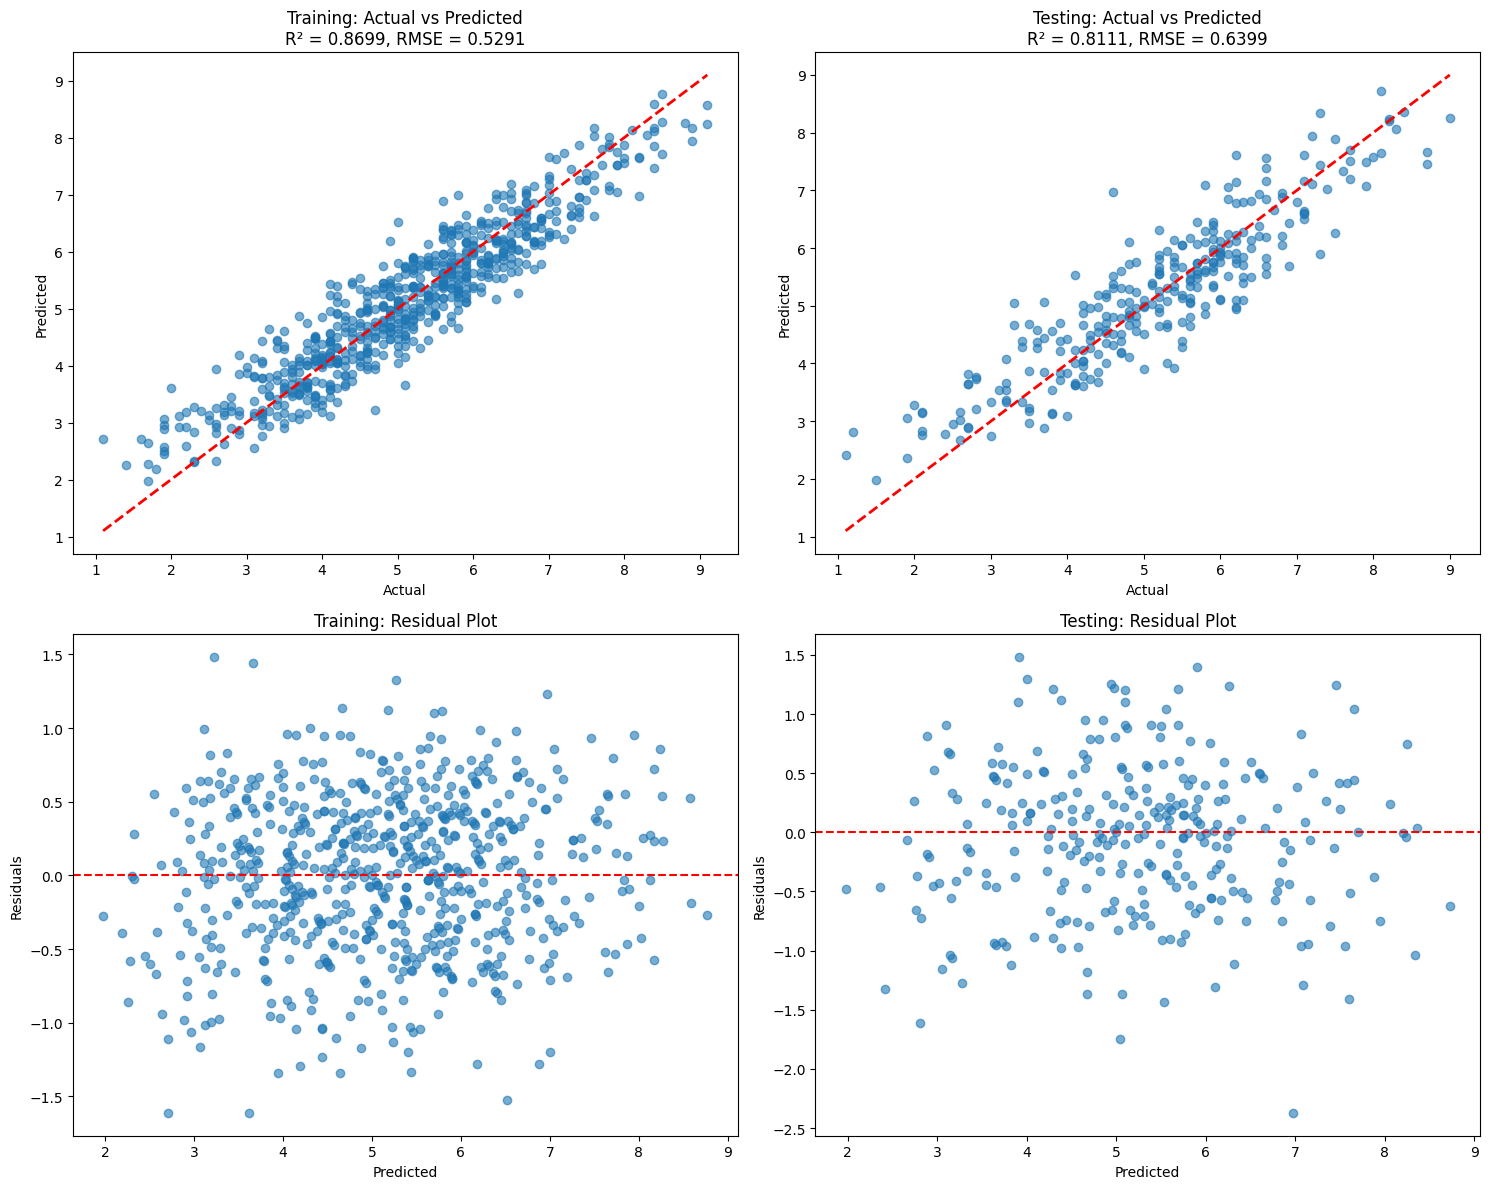

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6}

Training Metrics:
R²: 0.8699
RMSE: 0.5291

Testing Metrics:
R²: 0.8111
RMSE: 0.6399


In [28]:
# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted for Training
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Training: Actual vs Predicted\nR² = {train_r2:.4f}, RMSE = {train_rmse:.4f}')

# Plot 2: Actual vs Predicted for Testing
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Testing: Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}')

# Plot 3: Residuals for Training
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.6)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Training: Residual Plot')

# Plot 4: Residuals for Testing
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.6)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Testing: Residual Plot')

plt.tight_layout()
plt.show()

# Print metrics
print("Best Parameters:", grid_search.best_params_)
print("\nTraining Metrics:")
print(f"R²: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print("\nTesting Metrics:")
print(f"R²: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")

## Model Explanation with XAI

This section will focus on interpreting the trained model, understanding which features are most important for predictions, and explaining how individual predictions are made using techniques like SHAP or LIME.

In [29]:
import pickle

# Save the best model
filename = 'best_xgboost_model.pkl'
pickle.dump(best_model, open(filename, 'wb'))

print(f"Saved the best model to {filename}")

Saved the best model to best_xgboost_model.pkl


In [26]:
# Define features and target
X = dfclean[['Temperature', 'pH', 'Yeast_Concentration', 'Sugar_Concentration']]
y = dfclean['Residual_Sugar']

# Split data into 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0]
}

# Create XGBoost regressor
xgb_model = xgb.XGBRegressor(random_state=42)

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Print results
print("Best Parameters:", grid_search.best_params_)
print("\nTraining Metrics:")
print(f"R²: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print("\nTesting Metrics:")
print(f"R²: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6}

Training Metrics:
R²: 0.8699
RMSE: 0.5291

Testing Metrics:
R²: 0.8111
RMSE: 0.6399


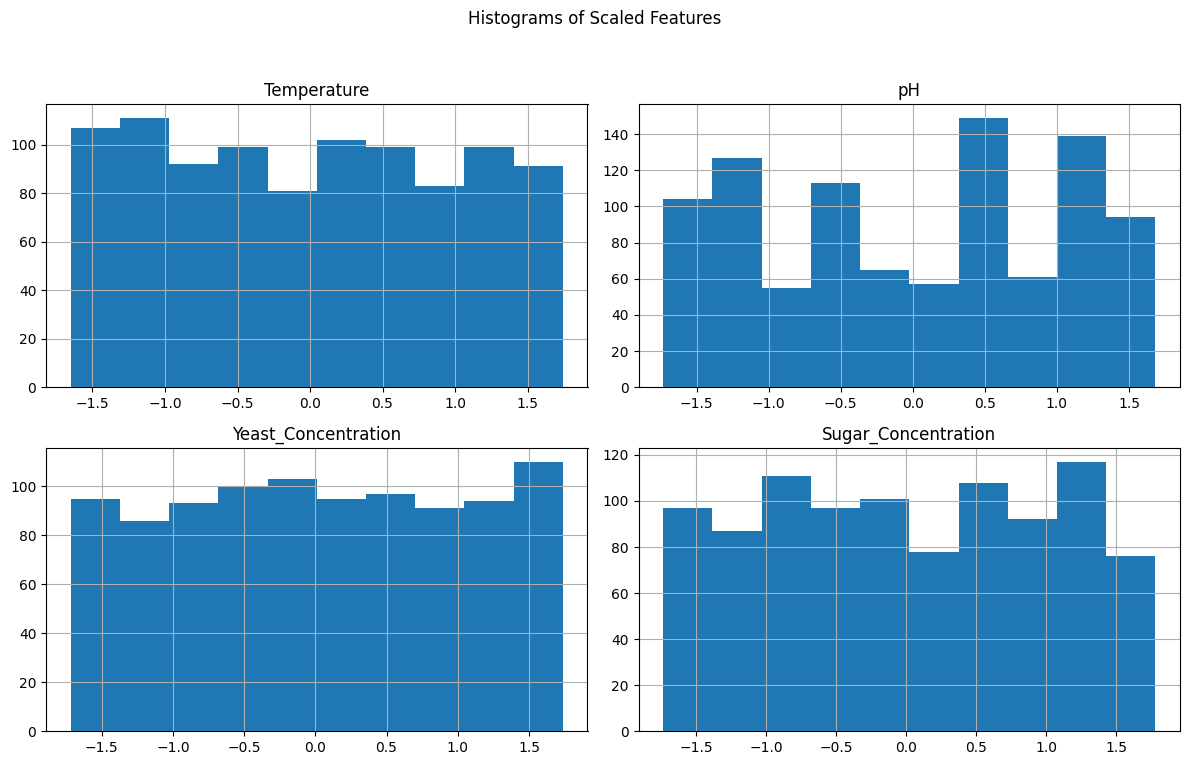

In [23]:
from sklearn.preprocessing import StandardScaler

# Normalize X data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame for easier plotting
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Plot histograms of scaled data
X_scaled_df.hist(figsize=(12, 8))
plt.suptitle('Histograms of Scaled Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

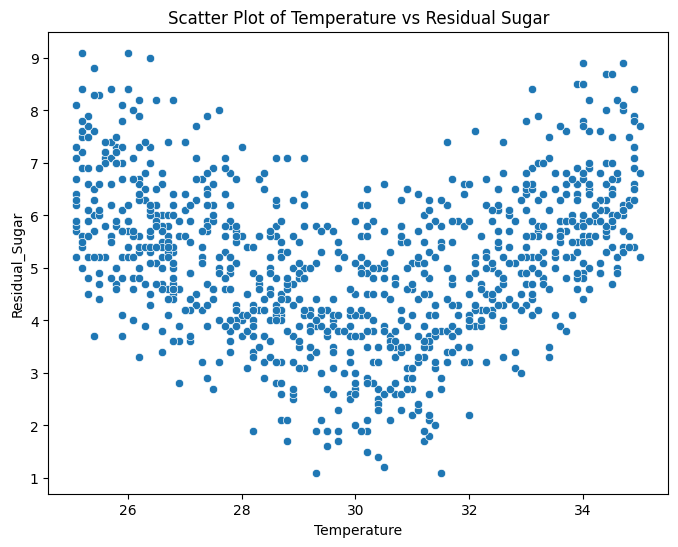

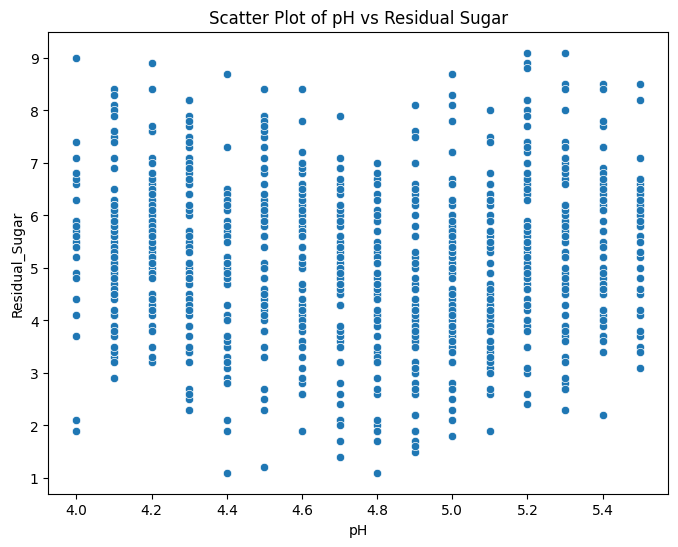

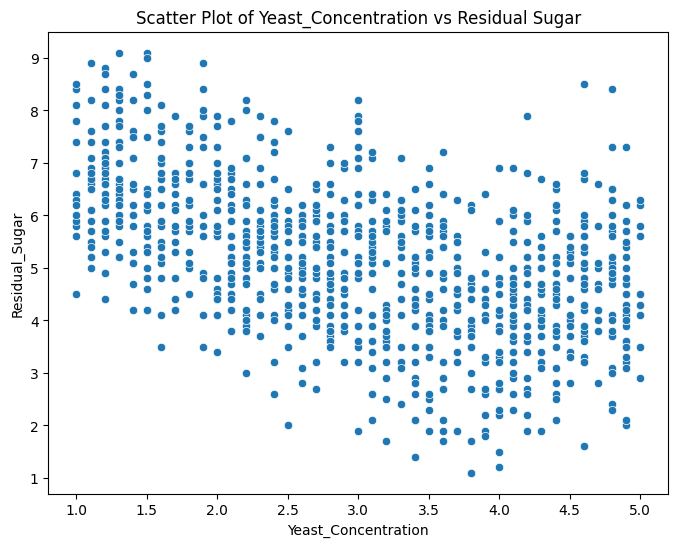

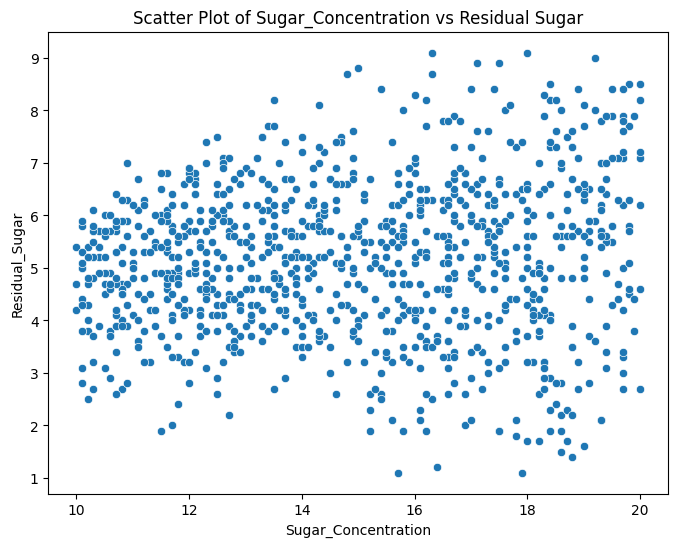

In [22]:
# Define features and target
X = dfclean[['Temperature', 'pH', 'Yeast_Concentration', 'Sugar_Concentration']]
y = dfclean['Residual_Sugar']

# Plot scatter plots between features and Y
for col in X.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=dfclean, x=col, y='Residual_Sugar')
    plt.title(f'Scatter Plot of {col} vs Residual Sugar')
    plt.xlabel(col)
    plt.ylabel('Residual_Sugar')
    plt.show()

Correlation Matrix:


,Temperature,pH,Yeast_Concentration,Sugar_Concentration,Residual_Sugar
Temperature,1.000000,-0.012451,-0.008779,-0.014722,-0.011687
pH,-0.012451,1.000000,0.015833,0.003738,-0.026576
Yeast_Concentration,-0.008779,0.015833,1.000000,0.006277,-0.510320
Sugar_Concentration,-0.014722,0.003738,0.006277,1.000000,0.102366
Residual_Sugar,-0.011687,-0.026576,-0.510320,0.102366,1.000000


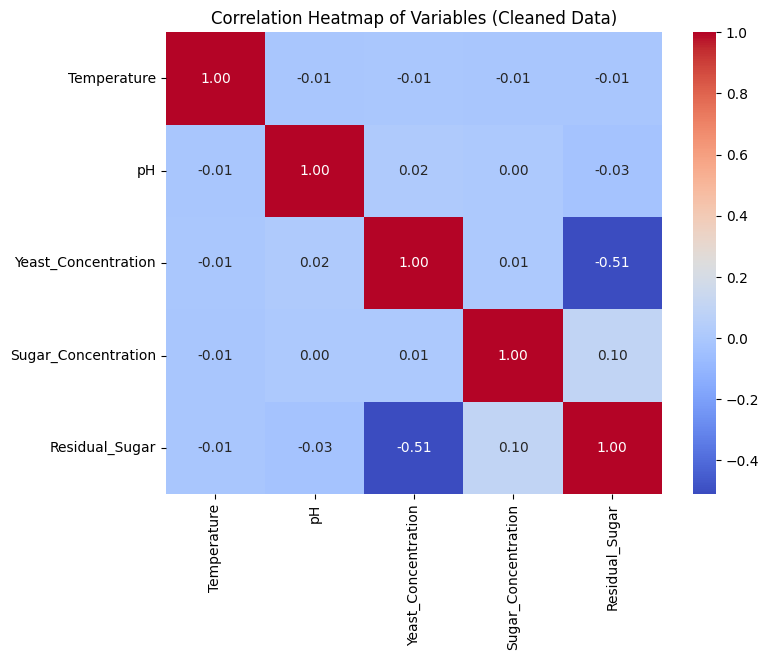

In [21]:
# Print correlations matrix
correlation_matrix = dfclean.corr()
print("Correlation Matrix:")
display(correlation_matrix)

# Plot a heatmap of correlation of dfclean
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Variables (Cleaned Data)')
plt.show()

In [14]:
print(f"Number of duplicate rows: {df_filled.duplicated().sum()}")

Number of duplicate rows: 0


In [15]:
display(df_filled.describe())

,Temperature,pH,Yeast_Concentration,Sugar_Concentration,Residual_Sugar
count,972.000000,972.000000,972.000000,972.000000,972.000000
mean,30.003807,4.760802,2.982510,14.961934,5.155041
std,3.649713,0.484015,1.160695,2.852478,1.510385
min,25.000000,0.100000,1.000000,10.000000,0.800000
25%,27.375000,4.400000,2.000000,12.500000,4.100000
50%,30.000000,4.800000,3.000000,14.950000,5.200000
75%,32.500000,5.100000,4.000000,17.400000,6.100000
max,82.000000,9.000000,5.000000,20.000000,10.900000


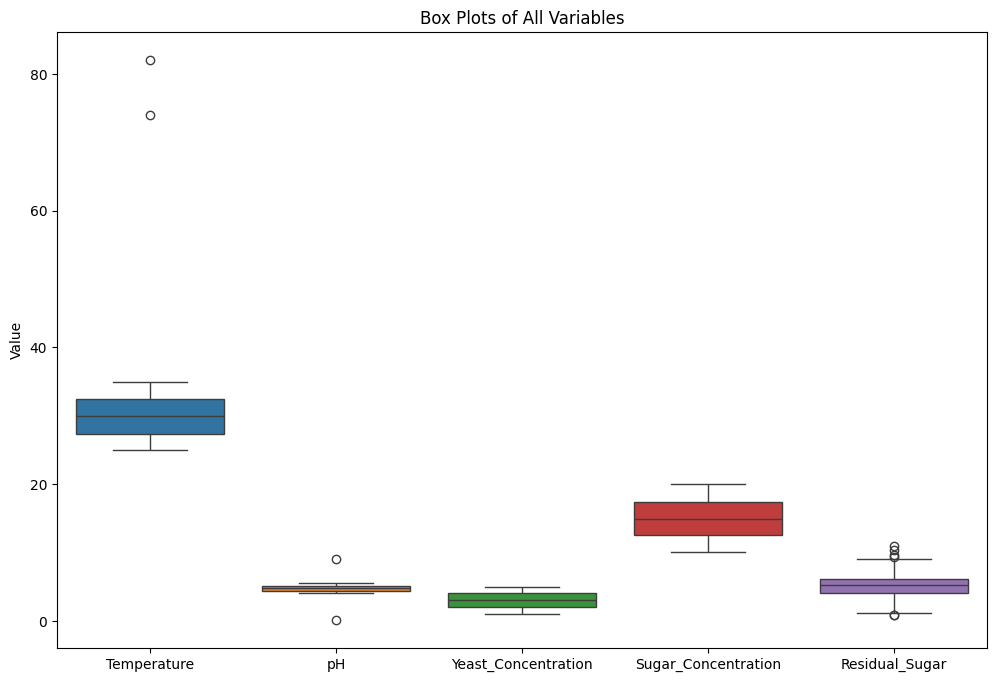

In [16]:
# Create box plots for all variables
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_filled)
plt.title('Box Plots of All Variables')
plt.ylabel('Value')
plt.show()

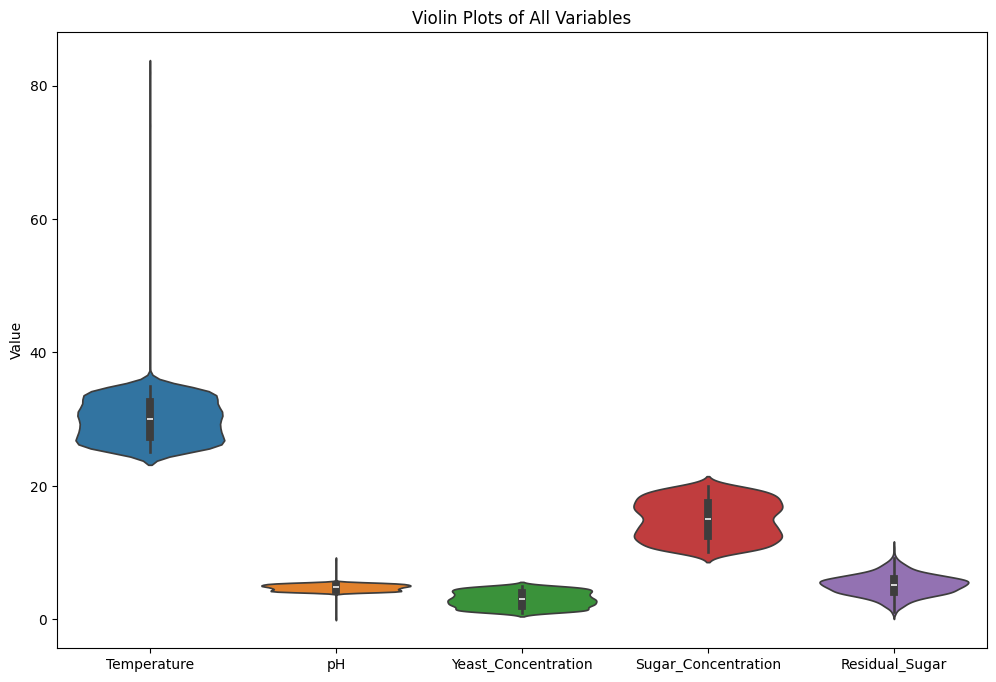

In [17]:
# Create violin plots for all variables
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_filled)
plt.title('Violin Plots of All Variables')
plt.ylabel('Value')
plt.show()

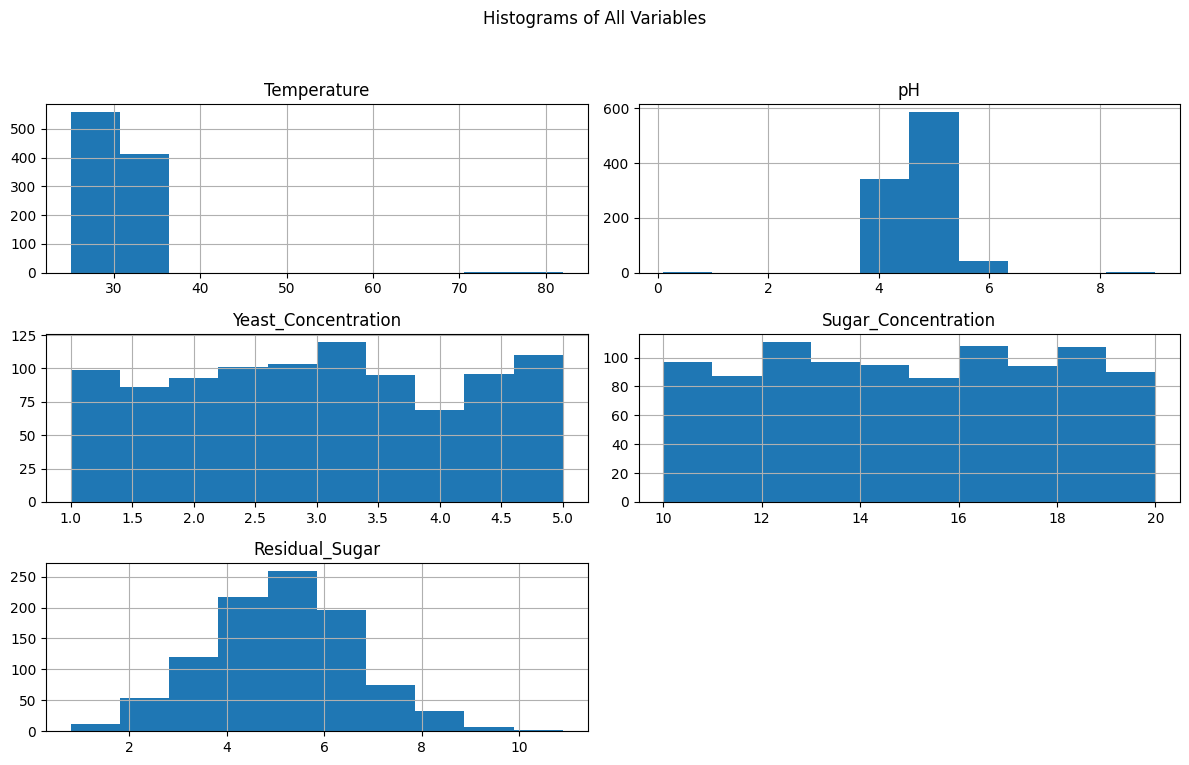

In [18]:
# Create histogram plots for all variables
df_filled.hist(figsize=(12, 8))
plt.suptitle('Histograms of All Variables')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [19]:
# Remove outliers using IQR method
Q1 = df_filled.quantile(0.25)
Q3 = df_filled.quantile(0.75)
IQR = Q3 - Q1

dfclean = df_filled[~((df_filled < (Q1 - 1.5 * IQR)) |(df_filled > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

print(f"Original DataFrame shape: {df_filled.shape}")
print(f"Cleaned DataFrame shape: {dfclean.shape}")

Original DataFrame shape: (972, 5)
Cleaned DataFrame shape: (964, 5)


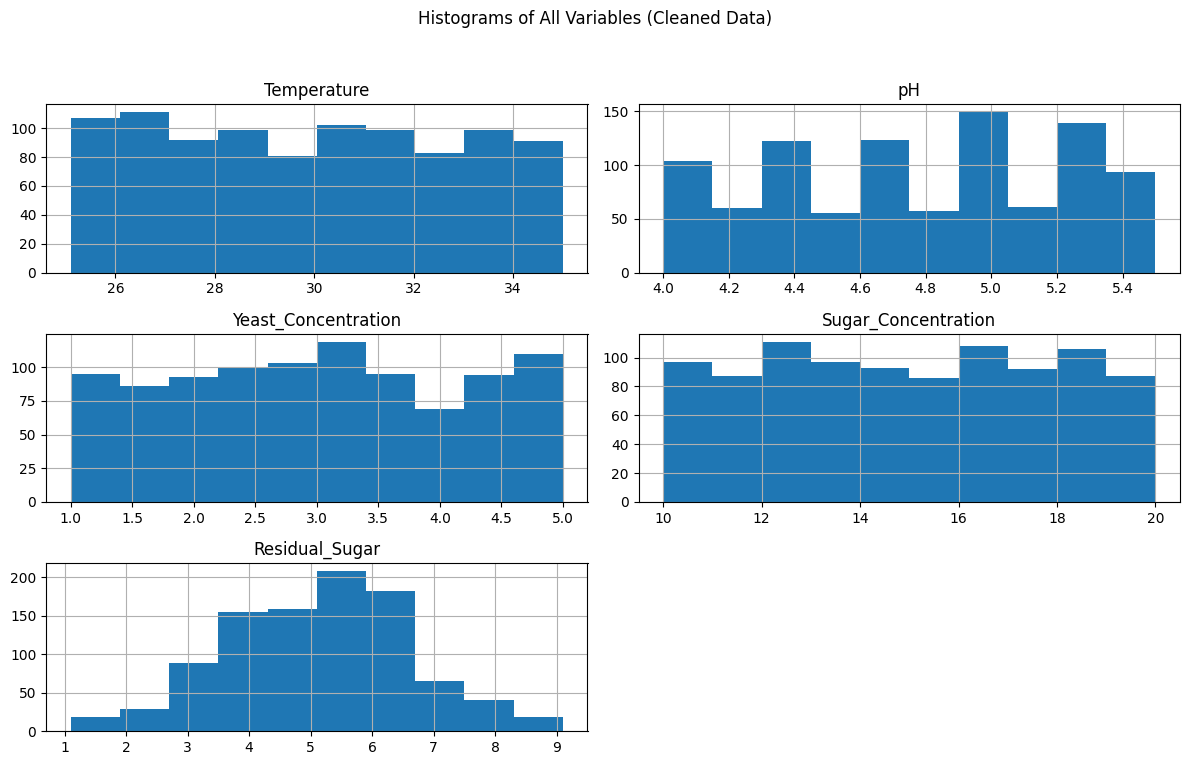

In [20]:
# Create histogram plots for all variables in dfclean
dfclean.hist(figsize=(12, 8))
plt.suptitle('Histograms of All Variables (Cleaned Data)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Check for duplicates

**Prompt:**

Check if it has duplicates

# Exploratory Dara Analysis (EDA)

## Summary Stats

**Prompt:**

## Data Visualization

### Data Visualization with Box Plot


![Box plot](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/boxplot.png?raw=1)


**Prompt:**

Create box plots for all variables in multiple plots in single figure. show outliers

In [ ]:
df_filled

,Temperature,pH,Yeast_Concentration,Sugar_Concentration,Residual_Sugar
0,28.7,5.0,1.2,12.30,5.3
1,34.5,5.4,2.3,10.00,5.4
2,32.3,5.1,4.1,17.30,3.2
3,31.0,4.3,3.8,19.70,2.7
4,26.6,4.0,4.2,12.20,5.5
...,...,...,...,...,...
967,28.0,5.2,1.9,18.80,7.3
968,30.7,4.7,2.2,15.60,4.7
969,29.8,4.1,2.2,12.30,3.8
970,82.0,0.1,3.0,14.95,4.0


### Data Visualization with Violine plot


![Violin plot](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/violinplot.png?raw=1)


**Prompt:**

Create violine plots for all variables in multiple plots in single figure.

### Data Visualization with Histogram plot

**Prompt:**

Create histogram plots for all variables in multiple plots in single figure.

## Outliers

**Strategy:** We will use statistical methods to remove outliers (IQR)

**Prompt:**

Remove all outliers of df using IQR method and create a table called dfclean

### Histogram plot with cleaned data

**Prompt:**

Create histogram plots for all variables in multiple plots in single figure using dfclean

## Corelinearity

**Prompt:**

Print correlations matrix and do a plot a heatmap of correlation of dfclean

# Data Prep for Model

## Define Features and Target

**Prompt:**

'Residual_Sugar' is Y variables and Temperature','pH','Yeast_Concentration','Sugar_Concentration' are features. Plot scatter plot between features and Y

## Feature Engineering with Data Scaling

**Prompt:**

Normalize X data using StandarScaler and plot histogram

# Model Selection


![Model guide](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/model_selection.png?raw=1)

# XGBoost Model


**Note:**

Since this is tree model which does not require feature scaling in general, we **will not** use scaled data for model fitting


<p style="font-size:25px; color:blue;text-align:left;">
    XGBoost
</p>



    🔘 XGBoost is a machine learning algorithm that builds multiple decision trees one after another, where each new tree tries to fix the errors made by the previous trees.

    🔘 It uses a method called gradient boosting, which helps improve prediction accuracy by combining many weak models into a stronger one.
    
    🔘The algorithm includes features to prevent overfitting, such as regularization and controlling how the trees grow.

    🔘 XGBoost can handle large datasets efficiently by using parallel processing to speed up training.

    🔘 It is widely used because it is fast, accurate, and works well for tasks like classification and regression, making it popular among beginners and experts alike.

![xgboost](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/xgboost.png?raw=1)

References:

[XGboost paper](https://arxiv.org/abs/1603.02754)

## Data Split

![data split](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/datasplit.jpg?raw=1)

**Prompt**

Split the data into training and testing sets.

## Hyperparameter Optimization
| Parameter             | Purpose                              | Simple Explanation | Default |
|-----------------------|--------------------------------------|--------------------|---------|
| `n_estimators`        | Number of decision trees             | More trees = more learning, but too many can overdo it. Like having more experts vote on the answer. <br> ✅ **Typical tuned range:** 100–300 | `100` |
| `max_depth`           | How deep each tree can go            | Controls complexity. Deeper = more detailed rules, but may memorize data. Like allowing more "if-then" steps. <br> ✅ **Typical tuned range:** 3–10 | `6` |
| `learning_rate`       | How fast the model learns            | Smaller = slow, steady improvement. Larger = fast but may overshoot. Like step size toward the goal. <br> ✅ **Typical tuned range:** 0.01 – 0.3 | `0.3` |
| `subsample`           | % of data used for each tree         | Uses only part of the data per tree to avoid overfitting. Like asking different small groups to learn. <br> ✅ **Typical tuned range:** 0.6 – 1.0 | `1.0` |
| `colsample_bytree`    | % of features used per tree          | Each tree uses only some columns (e.g., size, age, location). Prevents over-reliance on one feature. <br> ✅ **Typical tuned range:** 0.6 – 1.0 | `1.0` |
| `min_child_weight`    | Minimum data in a prediction box     | Stops trees from splitting too small. “Don’t make a rule unless at least a few examples agree.” <br> ✅ **Typical tuned range:** 1 – 7 | `1` |
| `gamma`               | Minimum improvement to split         | Only split if it clearly helps. Like saying: “Only add a rule if it makes things meaningfully better.” <br> ✅ **Typical tuned range:** 0 – 0.5 | `0` |
| `reg_alpha`           | Simplifies model (L1 penalty)        | Shrinks weak signals to zero. Helps when many inputs are noisy or irrelevant. <br> ✅ **Typical tuned range:** 0 – 1 | `0` |
| `reg_lambda`          | Smooths predictions (L2 penalty)     | Keeps predictions stable by avoiding extreme values. Works like a safety brake. <br> ✅ **Typical tuned range:** 1 – 2 | `1` |

### Grid Search

🔘 Grid Search is like trying all possible combinations of settings to find the best one — just like testing different oven temperatures and baking times to make the perfect cake.

🔘 It automatically tests every combination of hyperparameters (like learning_rate=0.1, max_depth=6) you specify, trains the model each time, and picks the one with the best performance.

🔘 It uses cross-validation (e.g., 5-fold) to ensure the result is reliable and not just lucky on one data split.

🔘 Think of it as "brute-force tuning" — thorough, systematic, and great for finding optimal settings, but can be slow with too many parameters.

*Example: If you test 5 values for max_depth, and 5 values for n_estimators, Grid Search will try all 5x5=25 combinations and tell you which works best.*
     


![grid](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/grid_search.png?raw=1)

## K-fold Cross validation

In K-fold cross-validation, the data is split into K equal parts (folds). The model is trained K times, each time leaving out one fold for testing and using the other K-1 folds for training. The final performance metric is averaged over all K runs. This approach uses the entire dataset for both training and testing, providing a more reliable estimate of model performance.


**Prompt:**

Finetune below hyperparamters of xgboost with 5 fold cross validation. Print R2/RMSE of testing and training

```
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0]
}

```

## Training

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb


# Define features and target
X = dfclean[['Temperature', 'pH', 'Yeast_Concentration', 'Sugar_Concentration']]
y = dfclean['Residual_Sugar']

# Split data into 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0]
}

# Create XGBoost regressor
xgb_model = xgb.XGBRegressor(random_state=42)

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Print results
print("Best Parameters:", grid_search.best_params_)
print("\nTraining Metrics:")
print(f"R²: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print("\nTesting Metrics:")
print(f"R²: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6}

Training Metrics:
R²: 0.8699
RMSE: 0.5291

Testing Metrics:
R²: 0.8111
RMSE: 0.6399


# Model Evaluation

**Prompt:**
Evaluate the model as below.
1. Plot actual vs predicted values for both train and test
2. Print R2/RMSE on the graph
3. Plot residual for both training and testing


## Residual Plot

![residual](https://github.com/dissabnd/Applied-AI-in-Chemical-and-Process-Engineering/blob/main/assets/residualplot.png?raw=1)


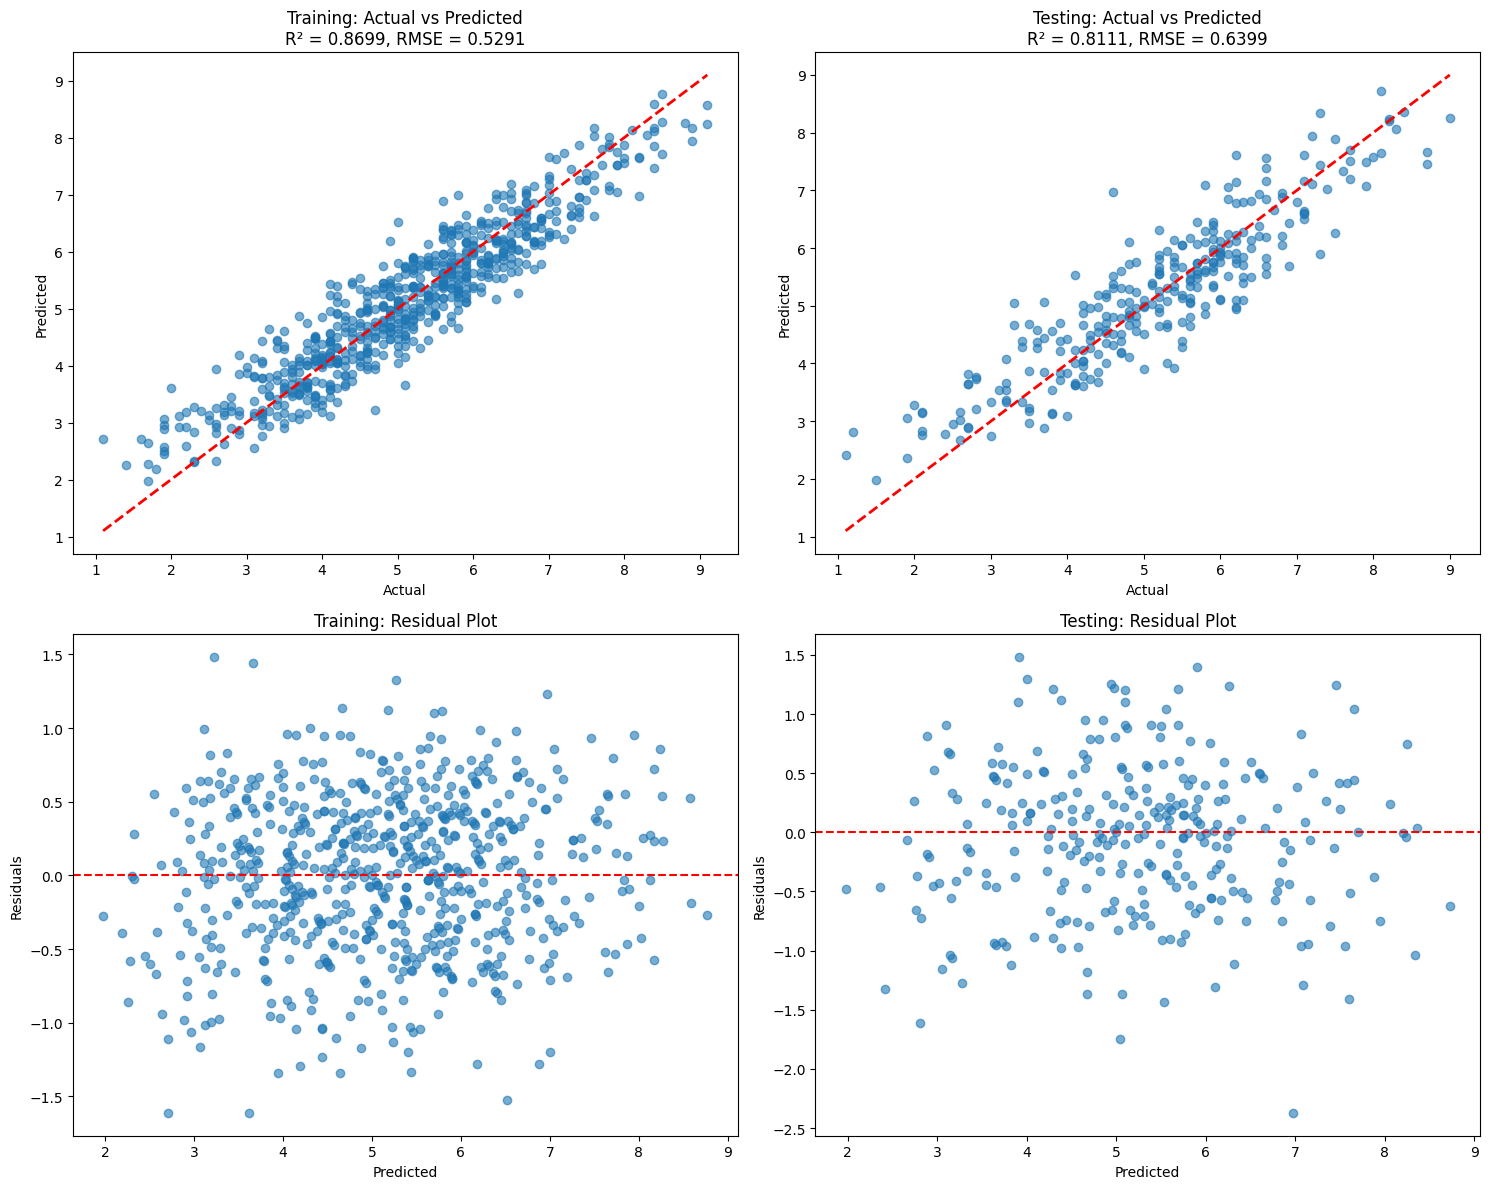

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6}

Training Metrics:
R²: 0.8699
RMSE: 0.5291

Testing Metrics:
R²: 0.8111
RMSE: 0.6399


In [30]:
# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted for Training
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Training: Actual vs Predicted\nR² = {train_r2:.4f}, RMSE = {train_rmse:.4f}')

# Plot 2: Actual vs Predicted for Testing
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Testing: Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}')

# Plot 3: Residuals for Training
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.6)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Training: Residual Plot')

# Plot 4: Residuals for Testing
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.6)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Testing: Residual Plot')

plt.tight_layout()
plt.show()

# Print metrics
print("Best Parameters:", grid_search.best_params_)
print("\nTraining Metrics:")
print(f"R²: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print("\nTesting Metrics:")
print(f"R²: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")

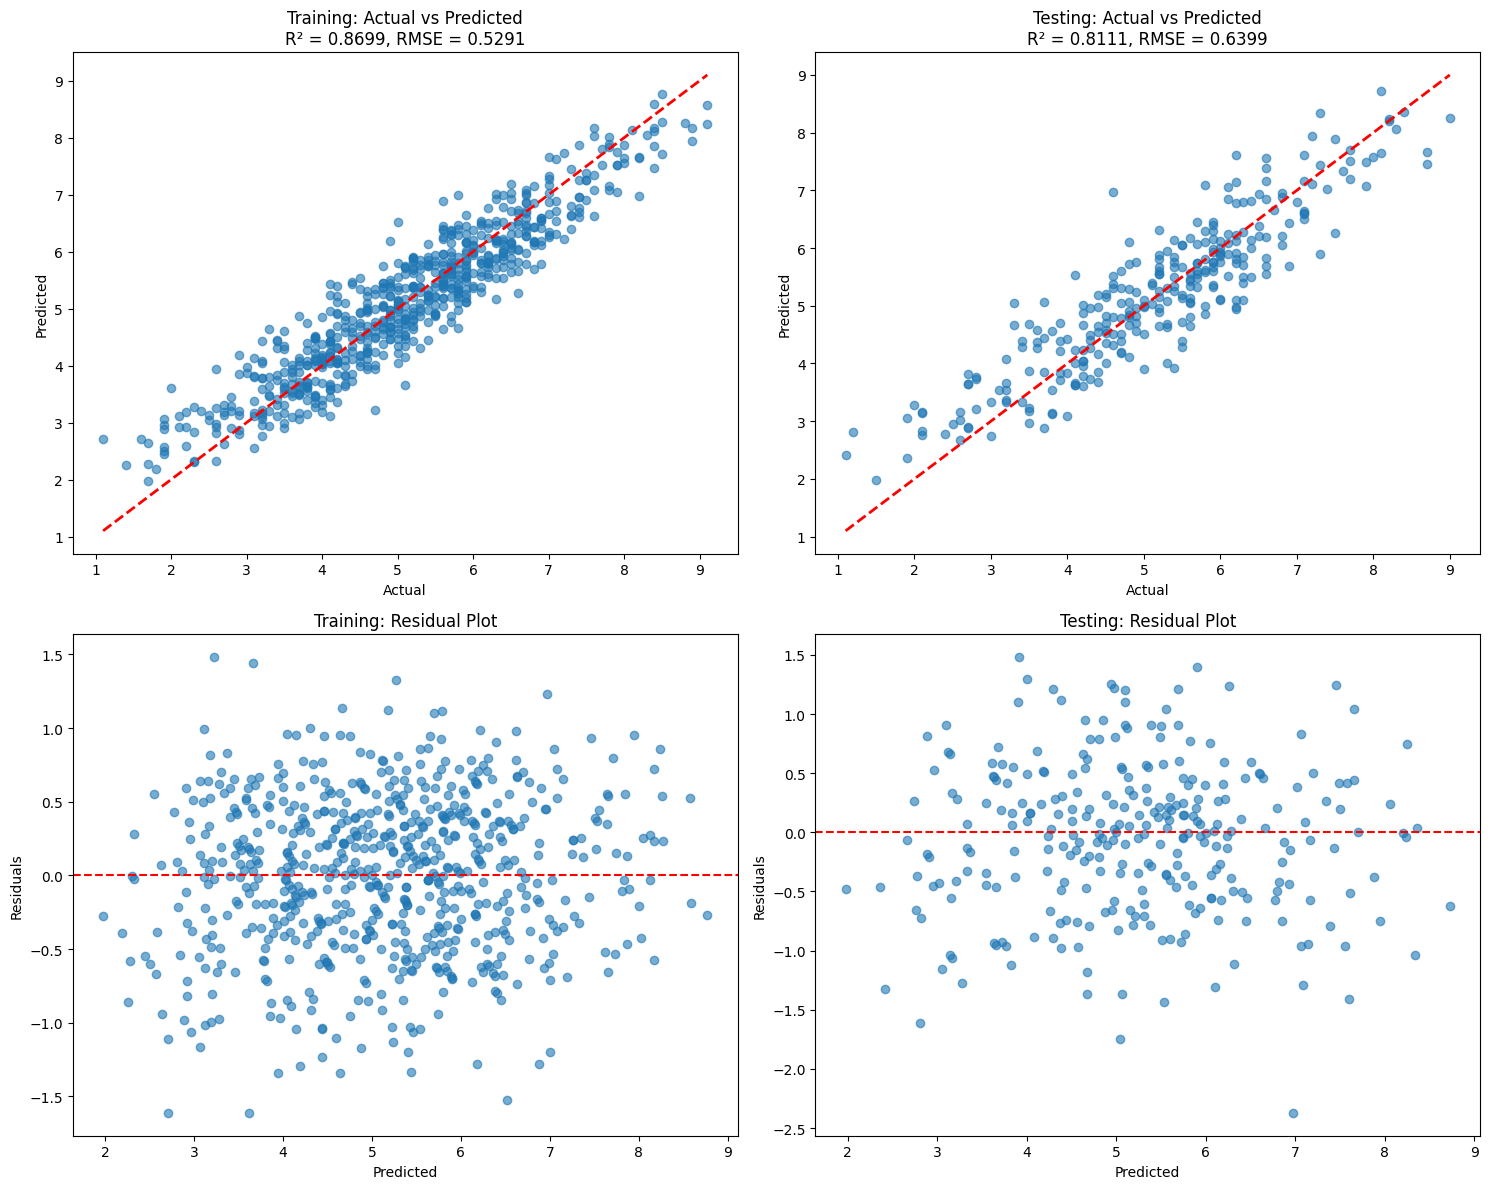

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6}

Training Metrics:
R²: 0.8699
RMSE: 0.5291

Testing Metrics:
R²: 0.8111
RMSE: 0.6399


In [ ]:
# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted for Training
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Training: Actual vs Predicted\nR² = {train_r2:.4f}, RMSE = {train_rmse:.4f}')

# Plot 2: Actual vs Predicted for Testing
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Testing: Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}')

# Plot 3: Residuals for Training
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.6)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Training: Residual Plot')

# Plot 4: Residuals for Testing
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.6)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Testing: Residual Plot')

plt.tight_layout()
plt.show()

# Print metrics
print("Best Parameters:", grid_search.best_params_)
print("\nTraining Metrics:")
print(f"R²: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print("\nTesting Metrics:")
print(f"R²: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")

## Save final model

**Prompt:**

Save the model in pickle format

## Model Explanation with XAI

This section will focus on interpreting the trained model, understanding which features are most important for predictions, and explaining how individual predictions are made using techniques like SHAP or LIME.

In [33]:
import pickle

# Save the best model
filename = 'best_xgboost_model.pkl'
pickle.dump(best_model, open(filename, 'wb'))

print(f"Saved the best model to {filename}")

Saved the best model to best_xgboost_model.pkl


# Model Explanation with XAI